In [1]:
import numpy as np
from pycbc.types import load_frequencyseries
from pycbc.psd import interpolate
import h5py

from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import cm 
plt.style.use('../paper.mplstyle')

/home/ian.harry/.conda/envs/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
input_data = '../datasets/LDC2_sangria_hm_training.hdf' # The Sangria dataset

In [3]:
# days before merger to use as cutoffs
cutoff_days = [0.5, 1, 4, 7, 14]

In [4]:
norm = mcolors.LogNorm(vmin=min(cutoff_days), vmax=max(cutoff_days))
cmap = cm.get_cmap('rainbow')
sm = cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

time_before_colors = {
    time_before: sm.to_rgba(time_before)
    for time_before in cutoff_days
}
time_before_colors[0] = 'k'

/tmp/ipykernel_199/2762826291.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('rainbow')


In [17]:

hc_all = {}
# lets just use mbhb 4 as an example
signals = range(15)
with h5py.File('characteristic_strain/collected_characteristic_strain.hdf','r') as ccsf:
    freqs = ccsf['frequencies'][:]
    delta_f = ccsf.attrs['delta_f']
    for sig_num in signals:
        print(f'Signal {sig_num}')
        hc_all[sig_num] = {}
        for cutoff_day in cutoff_days + [0]:
            hc_all[sig_num][cutoff_day] = \
                ccsf[str(sig_num)][str(cutoff_day).replace('.','p')][:]

Signal 0
Signal 1
Signal 2
Signal 3
Signal 4
Signal 5
Signal 6
Signal 7
Signal 8
Signal 9
Signal 10
Signal 11
Signal 12
Signal 13
Signal 14


In [18]:
hc_lb_all = {}
signals = range(15)
with h5py.File('characteristic_strain/collected_characteristic_strain_lb.hdf','r') as ccsf:
    freqs2 = ccsf['frequencies'][:]
    delta_f2 = ccsf.attrs['delta_f']
    for sig_num in signals:
        print(f'Signal {sig_num}')
        hc_lb_all[sig_num] = {}
        for cutoff_day in cutoff_days + [0]:
            hc_lb_all[sig_num][(cutoff_day, 'A')] = \
                ccsf[str(sig_num)][str(cutoff_day).replace('.','p') + 'A'][:]
            hc_lb_all[sig_num][(cutoff_day, 'E')] = \
                ccsf[str(sig_num)][str(cutoff_day).replace('.','p') + 'E'][:]

Signal 0
Signal 1
Signal 2
Signal 3
Signal 4
Signal 5
Signal 6
Signal 7
Signal 8
Signal 9
Signal 10
Signal 11
Signal 12
Signal 13
Signal 14


Lets compute the expected SNR from characteristic strain for each signal and each time before merger

In [19]:
# Typical PSD
psd_ = load_frequencyseries('model_AE_SMOOTHED_PSD.txt')

# interpolate the PSD so that it matches the signal PSD
psd = interpolate(psd_, delta_f)
psd2 = interpolate(psd_, delta_f2)
psd[0] = 0
psd2[0] = 0
psd.resize(len(freqs))
psd2.resize(len(freqs2))



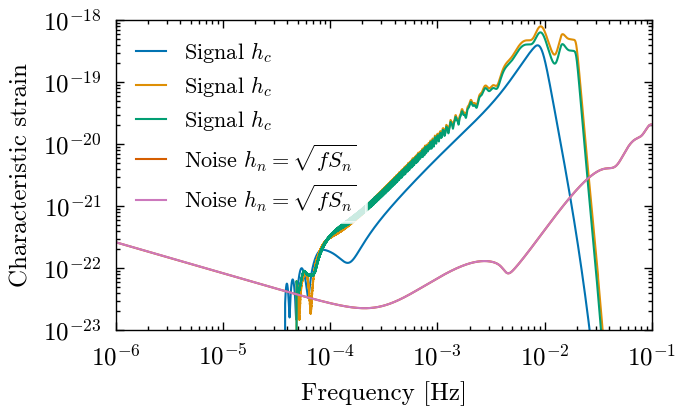

In [21]:


# Plot an example
hn = np.sqrt(freqs * psd)  # characteristic noise curve
hn2 = np.sqrt(freqs2 * psd2)  # characteristic noise curve

fig, ax  = plt.subplots(1)
print
ax.loglog(freqs, hc_all[4][0], label='Signal $h_c$')
ax.loglog(freqs2, hc_lb_all[4][(0,'A')], label='Signal $h_c$')
ax.loglog(freqs2, hc_lb_all[4][(0,'E')], label='Signal $h_c$')
ax.loglog(freqs, hn, label='Noise $h_n = \sqrt{f S_n}$')
ax.loglog(freqs2, hn2, label='Noise $h_n = \sqrt{f S_n}$')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic strain')
ax.set_ylim(1e-23, 1e-18)
ax.set_xlim(1e-6, 0.1)
ax.legend()

In [22]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_days = mbhb_sky[0]['CoalescenceTime'] / 86400

table_str = """\\begin{tabular}{|cc|c|ccccc|}
\\hline
\\multicolumn{2}{|c|}{Signal}& \multicolumn{6}{c|}{Expected SNR} \\\\
\\hline
Number & Time  & Full Signal & 0.5 & 1 & 4 & 7 & 14 \\\\
\\hline
"""
for sig_num, days in zip(signals, truth_times_days):
    table_row = f"{sig_num} & {days:.2f}"
    for cutoff_day in [0] + cutoff_days:
        h_c_tbefore  = hc_all[sig_num][cutoff_day]
        valid = h_c_tbefore > 0
        snr2 = np.trapezoid((h_c_tbefore[valid] / hn[valid])**2, np.log(freqs[valid]))
        snr = np.sqrt(snr2)
        table_row += f" & {snr:.2f}"
    table_row += " \\\\\n"
    table_str += table_row
table_str += """\\hline
\\end{tabular}"""

with open("../paper/characteristic_strain_table.tex", 'w') as table_file:
    table_file.write(table_str)
    print(table_str)

    

\begin{tabular}{|cc|c|ccccc|}
\hline
\multicolumn{2}{|c|}{Signal}& \multicolumn{6}{c|}{Expected SNR} \\
\hline
Number & Time  & Full Signal & 0.5 & 1 & 4 & 7 & 14 \\
\hline
0 & 55.56 & 1545.67 & 41.96 & 31.17 & 14.24 & 9.45 & 5.23 \\
1 & 101.23 & 243.12 & 11.59 & 7.51 & 2.79 & 1.80 & 1.00 \\
2 & 129.26 & 500.39 & 15.47 & 11.16 & 4.95 & 3.42 & 2.14 \\
3 & 130.31 & 3037.79 & 111.61 & 85.14 & 42.70 & 30.53 & 19.84 \\
4 & 133.41 & 1293.42 & 34.54 & 24.90 & 10.42 & 7.33 & 5.71 \\
5 & 138.55 & 55.58 & 2.83 & 1.95 & 0.90 & 0.68 & 0.49 \\
6 & 157.61 & 334.76 & 17.82 & 11.98 & 4.98 & 3.53 & 2.33 \\
7 & 191.34 & 915.85 & 27.34 & 18.60 & 6.89 & 4.24 & 2.12 \\
8 & 199.60 & 380.52 & 23.46 & 15.46 & 5.30 & 3.09 & 1.35 \\
9 & 215.34 & 154.88 & 8.63 & 5.69 & 2.12 & 1.39 & 0.84 \\
10 & 236.41 & 2270.66 & 49.27 & 35.26 & 14.79 & 9.81 & 5.53 \\
11 & 257.27 & 657.01 & 25.76 & 19.13 & 8.48 & 5.67 & 3.27 \\
12 & 271.29 & 165.68 & 11.70 & 8.06 & 3.23 & 2.16 & 1.33 \\
13 & 282.51 & 295.14 & 6.29 & 4.32 & 1.64

In [25]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_days = mbhb_sky[0]['CoalescenceTime'] / 86400

table_str = """\\begin{tabular}{|cc|c|ccccc|}
\\hline
\\multicolumn{2}{|c|}{Signal}& \multicolumn{6}{c|}{Expected SNR} \\\\
\\hline
Number & Time  & Full Signal & 0.5 & 1 & 4 & 7 & 14 \\\\
\\hline
"""
for sig_num, days in zip(signals, truth_times_days):
    table_row = f"{sig_num} & {days:.2f}"
    for cutoff_day in [0] + cutoff_days:
        h_c_tbeforeA  = hc_lb_all[sig_num][(cutoff_day,'A')]
        valid = h_c_tbeforeA > 0
        snr2A = np.trapezoid((h_c_tbeforeA[valid] / hn2[valid])**2, np.log(freqs2[valid]))
        h_c_tbeforeE  = hc_lb_all[sig_num][(cutoff_day,'E')]
        valid = h_c_tbeforeE > 0
        snr2E = np.trapezoid((h_c_tbeforeE[valid] / hn2[valid])**2, np.log(freqs2[valid]))
        snr = np.sqrt(snr2A + snr2E)
        table_row += f" & {snr:.2f}"
    table_row += " \\\\\n"
    table_str += table_row
table_str += """\\hline
\\end{tabular}"""

with open("../paper/characteristic_strain_table.tex", 'w') as table_file:
    table_file.write(table_str)
    print(table_str)

    

\begin{tabular}{|cc|c|ccccc|}
\hline
\multicolumn{2}{|c|}{Signal}& \multicolumn{6}{c|}{Expected SNR} \\
\hline
Number & Time  & Full Signal & 0.5 & 1 & 4 & 7 & 14 \\
\hline
0 & 55.56 & 2699.03 & 70.98 & 52.74 & 24.33 & 16.43 & 9.50 \\
1 & 101.23 & 105.72 & 3.99 & 2.49 & 0.79 & 0.47 & 0.28 \\
2 & 129.26 & 400.25 & 10.76 & 7.51 & 2.91 & 1.84 & 1.07 \\
3 & 130.31 & 1992.37 & 71.91 & 54.76 & 27.52 & 19.88 & 13.22 \\
4 & 133.41 & 3475.26 & 115.99 & 88.26 & 44.03 & 31.65 & 20.46 \\
5 & 138.55 & 427.13 & 16.40 & 10.79 & 3.85 & 2.36 & 1.22 \\
6 & 157.61 & 673.48 & 24.99 & 16.19 & 5.48 & 3.25 & 1.55 \\
7 & 191.34 & 579.12 & 15.72 & 10.70 & 4.02 & 2.56 & 1.49 \\
8 & 199.60 & 365.18 & 16.21 & 10.68 & 3.77 & 2.28 & 1.11 \\
9 & 215.34 & 392.96 & 18.69 & 12.41 & 4.75 & 3.12 & 1.82 \\
10 & 236.41 & 2187.77 & 45.09 & 31.90 & 12.71 & 8.13 & 4.37 \\
11 & 257.27 & 1200.55 & 45.31 & 33.31 & 13.99 & 8.93 & 4.71 \\
12 & 271.29 & 359.02 & 21.27 & 14.71 & 6.10 & 4.17 & 2.57 \\
13 & 282.51 & 822.99 & 24.75 & 1